# 04 — Clustering: K-Means, HAC & Cluster Profiling

**Goal:** Find natural student groupings based on academic performance,
profile each cluster, and visualise the structure.

**Pipeline:**
1. Prepare feature matrix (PCA scores or raw grades)
2. Choose optimal K (elbow, silhouette, gap statistic)
3. K-Means clustering
4. Hierarchical Agglomerative Clustering (HAC) + dendrogram
5. Compare K-Means vs HAC
6. Profile clusters: who is in each group?



## 1. Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings("ignore")

CLEAN = Path("../data/clean")
FIG   = Path("../figures/clustering")
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

panel = pd.read_csv(CLEAN / "panel.csv")

# Feature selection — performance-based
base_cols = ["moy_s1", "moy_s2", "moy_ann", "delta_s2_s1", "rang_norm"]
grade_cols = [c for c in panel.columns
              if c not in ["id","promo","moy_s1","moy_s2","moy_ann","rang",
                            "passage","passage_bin","rang_norm","delta_s2_s1",
                            "top_quartile","bottom_quartile","is_outlier",
                            "genre","origine","bac","licence","promotion"]
              and not c.startswith("mod_")]
mod_cols = [c for c in panel.columns if c.startswith("mod_")]

all_feat = base_cols + grade_cols + mod_cols
feat_cols = [c for c in all_feat if c in panel.columns]
print(f"Feature columns for clustering: {feat_cols}")


Feature columns for clustering: ['moy_s1', 'moy_s2', 'moy_ann', 'delta_s2_s1', 'rang_norm', 'Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind', 'mod_Big Data & Cloud', 'mod_Développement 5', 'mod_IA & Virtualisation', 'mod_ML, DevOp & dev mobile', 'mod_Mathématiques 5', 'mod_Mathématiques 6', 'mod_Sémantique & Sys distribué', 'mod_Th info, entrepot & IHM']


## 2. Prepare Feature Matrix



In [2]:
data = panel[["id", "promo", "passage"] + feat_cols].dropna(subset=feat_cols)
X = data[feat_cols].values
ids    = data["id"].values
promos = data["promo"].values

scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

# Reduce with PCA to 2-5 components for clustering
# (avoids curse of dimensionality; we keep enough variance)
n_pca = min(len(feat_cols), max(2, len(feat_cols)//2))
pca   = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_std)

pca_var = pca.explained_variance_ratio_.cumsum()
print(f"PCA {n_pca} components explain {pca_var[-1]*100:.1f}% variance")
print(f"Clustering on {n_pca}-dim PCA space (n={len(X_std)} students)")

# Use 2D for visualisation throughout
X_2d = X_pca[:, :2]


PCA 19 components explain 96.0% variance
Clustering on 19-dim PCA space (n=100 students)


## 3. Choose Optimal K

Three criteria: Elbow (inertia), Silhouette score, Davies-Bouldin index.



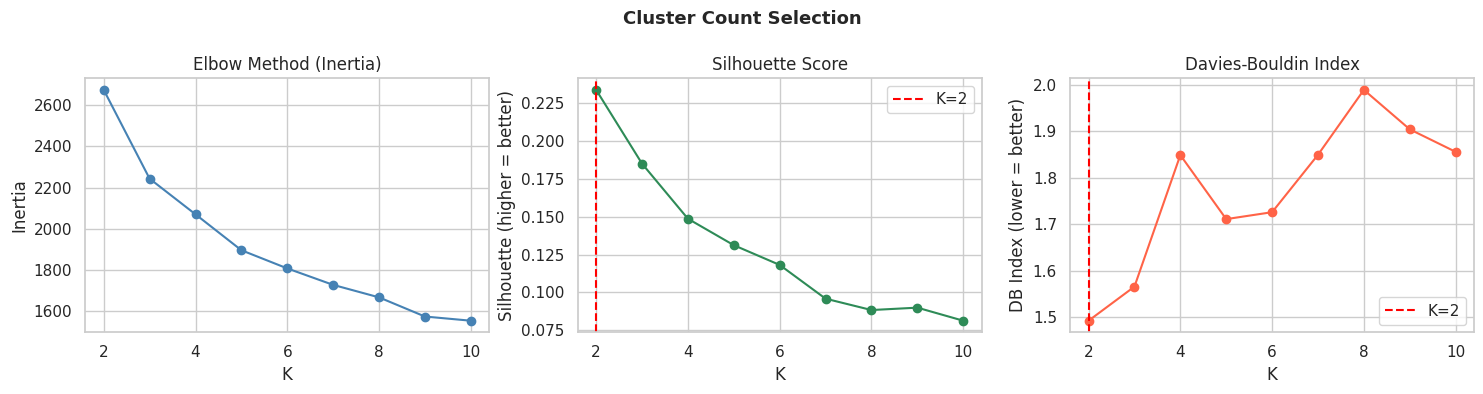


Chosen K = 2  (silhouette best=2, DB best=2)


In [3]:
K_range = range(2, min(11, len(data) // 3))
inertias, silhouettes, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(K_range), inertias, "o-", color="steelblue")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouettes, "o-", color="seagreen")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette (higher = better)")
best_k_sil = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, color="red", lw=1.5, linestyle="--", label=f"K={best_k_sil}")
axes[1].legend()

axes[2].plot(list(K_range), db_scores, "o-", color="tomato")
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("K")
axes[2].set_ylabel("DB Index (lower = better)")
best_k_db = list(K_range)[np.argmin(db_scores)]
axes[2].axvline(best_k_db, color="red", lw=1.5, linestyle="--", label=f"K={best_k_db}")
axes[2].legend()

plt.suptitle("Cluster Count Selection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "cluster_selection.png", dpi=150)
plt.show()

# Choose K by majority vote between silhouette and DB
K_best = best_k_sil
print(f"\nChosen K = {K_best}  (silhouette best={best_k_sil}, DB best={best_k_db})")


## 4. K-Means Clustering



K-Means cluster sizes:
cluster_km
0    63
1    37
Name: count, dtype: int64

Overall silhouette: 0.234
Per-cluster silhouette:
cluster_km
0   0.27
1   0.17
Name: silhouette, dtype: float64


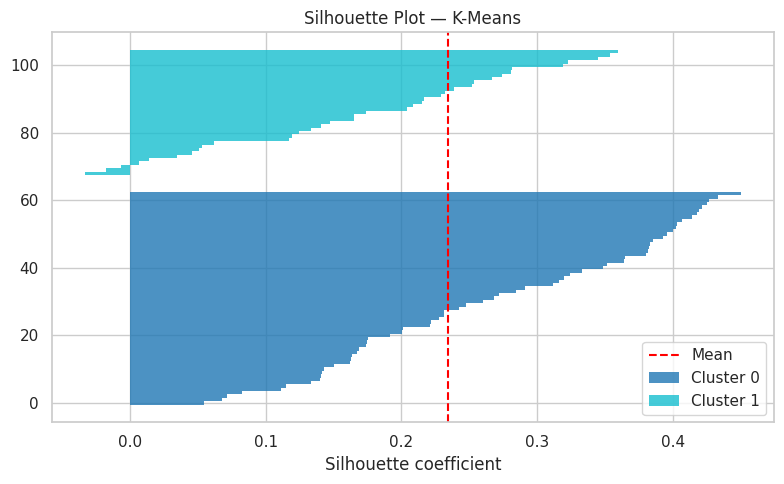

In [4]:
km = KMeans(n_clusters=K_best, random_state=42, n_init=15)
data["cluster_km"] = km.fit_predict(X_pca)

# Cluster sizes
print("K-Means cluster sizes:")
print(data["cluster_km"].value_counts().sort_index())

# Silhouette plot
sil_vals = silhouette_samples(X_pca, data["cluster_km"])
data["silhouette"] = sil_vals
print(f"\nOverall silhouette: {silhouette_score(X_pca, data['cluster_km']):.3f}")
print(f"Per-cluster silhouette:")
print(data.groupby("cluster_km")["silhouette"].mean().round(3))

# Silhouette bar plot
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = 0
cluster_colors = plt.cm.tab10(np.linspace(0, 1, K_best))
for cl in range(K_best):
    sil_cl = np.sort(sil_vals[data["cluster_km"] == cl])
    ax.barh(range(y_pos, y_pos + len(sil_cl)), sil_cl, height=1.0,
            color=cluster_colors[cl], edgecolor="none", alpha=0.8,
            label=f"Cluster {cl}")
    y_pos += len(sil_cl) + 5
ax.axvline(silhouette_score(X_pca, data["cluster_km"]), color="red",
           lw=1.5, linestyle="--", label="Mean")
ax.set_xlabel("Silhouette coefficient")
ax.set_title("Silhouette Plot — K-Means")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "kmeans_silhouette.png", dpi=150)
plt.show()


### 4a. K-Means Cluster Scatter



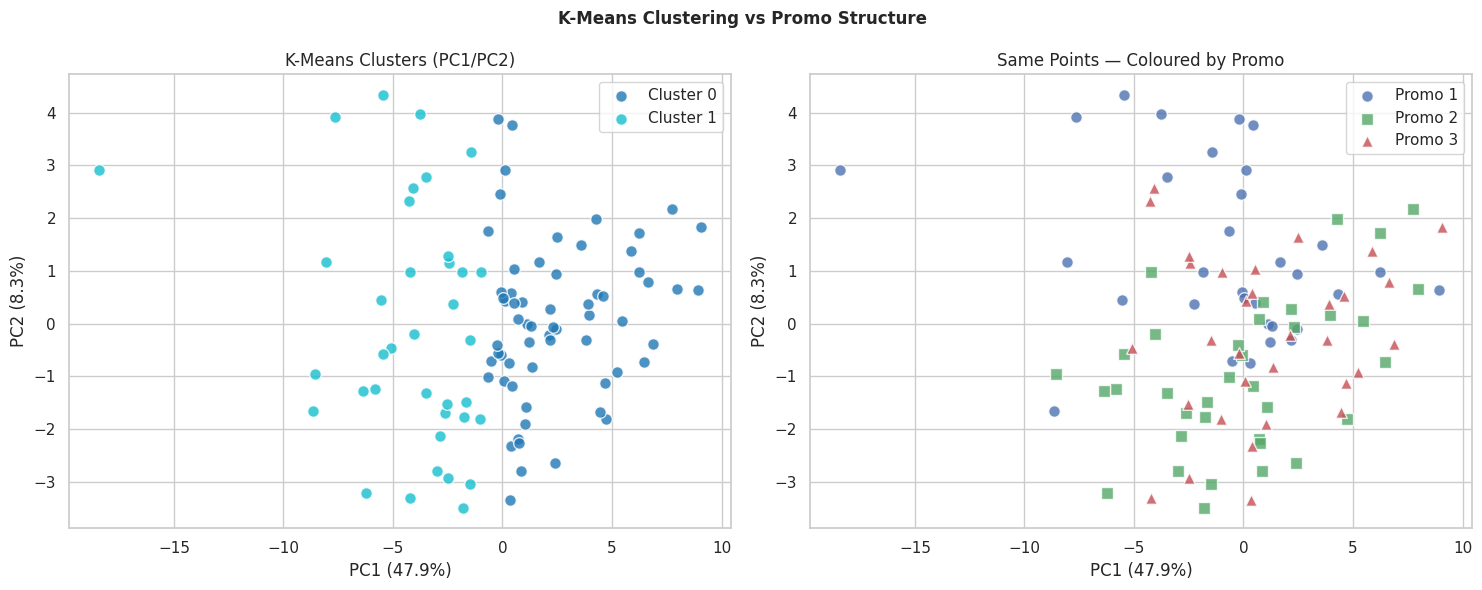

In [5]:
PROMO_MARKERS = {1: "o", 2: "s", 3: "^"}
PROMO_COLORS  = {1: "#4C72B0", 2: "#55A868", 3: "#C44E52"}
pca_var_ratio = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: coloured by K-Means cluster
ax = axes[0]
colors_km = plt.cm.tab10(np.linspace(0, 0.9, K_best))
for cl in range(K_best):
    mask = data["cluster_km"] == cl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors_km[cl], alpha=0.8, s=70,
               edgecolors="white", label=f"Cluster {cl}")
ax.set_title("K-Means Clusters (PC1/PC2)")
ax.set_xlabel(f"PC1 ({pca_var_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_var_ratio[1]*100:.1f}%)")
ax.legend()

# Right: coloured by promo to see overlap
ax = axes[1]
for promo in [1, 2, 3]:
    mask = promos == promo
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=PROMO_COLORS[promo], marker=PROMO_MARKERS[promo],
               alpha=0.8, s=70, edgecolors="white", label=f"Promo {promo}")
ax.set_title("Same Points — Coloured by Promo")
ax.set_xlabel(f"PC1 ({pca_var_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_var_ratio[1]*100:.1f}%)")
ax.legend()

plt.suptitle("K-Means Clustering vs Promo Structure", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "kmeans_scatter.png", dpi=150)
plt.show()


## 5. Hierarchical Agglomerative Clustering (HAC)



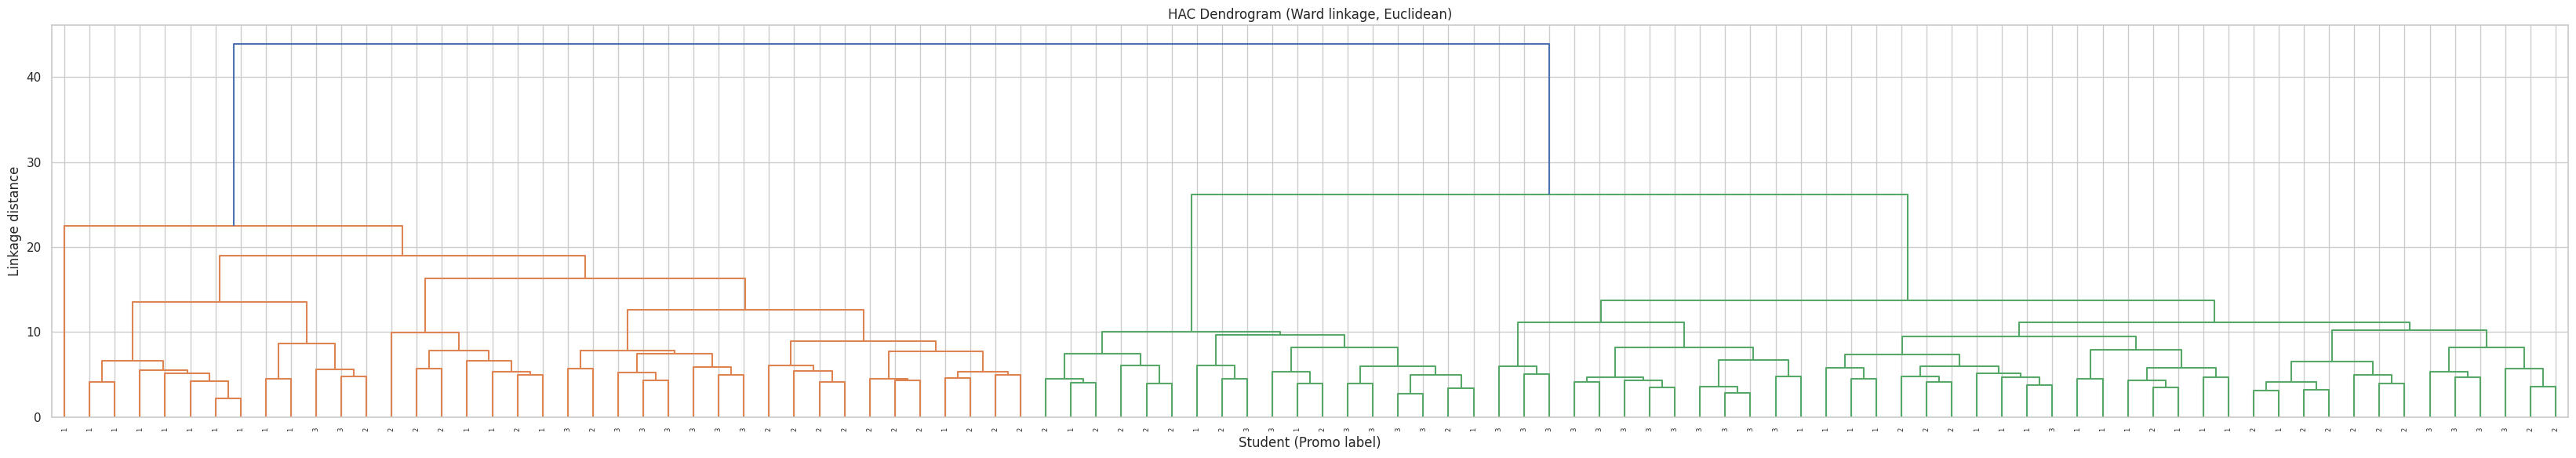

HAC cluster sizes:
cluster_hac
0    39
1    61
Name: count, dtype: int64

HAC silhouette: 0.205


In [6]:
# Compute full linkage matrix for dendrogram
linkage_matrix = linkage(X_pca, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(max(12, len(data)//3), 6))
dend = dendrogram(linkage_matrix,
                  labels=[f"{p}" for p in promos],
                  leaf_rotation=90,
                  leaf_font_size=6,
                  color_threshold=0.7 * max(linkage_matrix[:, 2]),
                  ax=ax)
ax.set_title("HAC Dendrogram (Ward linkage, Euclidean)", fontsize=12)
ax.set_xlabel("Student (Promo label)")
ax.set_ylabel("Linkage distance")
plt.tight_layout()
plt.savefig(FIG / "hac_dendrogram.png", dpi=150)
plt.show()

# Cut tree at K_best clusters
data["cluster_hac"] = fcluster(linkage_matrix, t=K_best, criterion="maxclust") - 1
print("HAC cluster sizes:")
print(data["cluster_hac"].value_counts().sort_index())
print(f"\nHAC silhouette: {silhouette_score(X_pca, data['cluster_hac']):.3f}")


### 5a. HAC Scatter



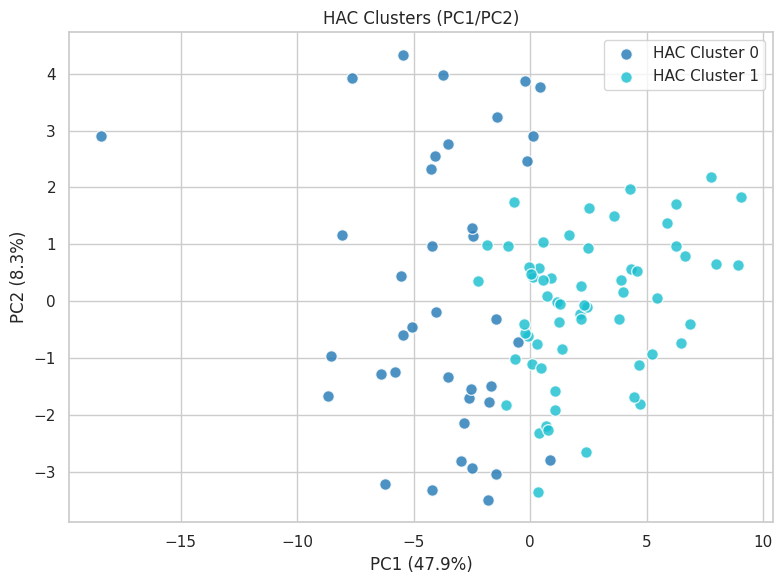

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_hac = plt.cm.tab10(np.linspace(0, 0.9, K_best))
for cl in range(K_best):
    mask = data["cluster_hac"] == cl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors_hac[cl], alpha=0.8, s=70,
               edgecolors="white", label=f"HAC Cluster {cl}")
ax.set_title("HAC Clusters (PC1/PC2)")
ax.set_xlabel(f"PC1 ({pca_var_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_var_ratio[1]*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "hac_scatter.png", dpi=150)
plt.show()


## 6. Compare K-Means vs HAC



In [8]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari   = adjusted_rand_score(data["cluster_km"], data["cluster_hac"])
nmi   = normalized_mutual_info_score(data["cluster_km"], data["cluster_hac"])

print(f"K-Means vs HAC agreement:")
print(f"  Adjusted Rand Index (ARI): {ari:.3f}  (1=perfect, 0=random)")
print(f"  Normalised Mutual Info   : {nmi:.3f}")

cross = pd.crosstab(data["cluster_km"], data["cluster_hac"],
                    rownames=["K-Means"], colnames=["HAC"])
print(f"\nCross-tabulation:\n{cross}")


K-Means vs HAC agreement:
  Adjusted Rand Index (ARI): 0.636  (1=perfect, 0=random)
  Normalised Mutual Info   : 0.518

Cross-tabulation:
HAC       0   1
K-Means        
0         6  57
1        33   4


## 7. Cluster Profiling

Which cluster is "high performers"? "at-risk"? "average"?



In [9]:
# Join cluster labels back to panel
panel_cl = panel.copy()
panel_cl = panel_cl.merge(data[["id", "promo", "cluster_km", "cluster_hac"]],
                           on=["id", "promo"], how="left")

profile_cols = ["moy_s1", "moy_s2", "moy_ann", "delta_s2_s1", "rang",
                "passage_bin", "rang_norm"] + grade_cols
profile_cols = [c for c in profile_cols if c in panel_cl.columns]

print("=== K-Means Cluster Profiles ===")
profile_km = panel_cl.groupby("cluster_km")[profile_cols].mean().round(2)
print(profile_km)

# Assign descriptive labels based on moy_ann
if "moy_ann" in profile_km.columns:
    mean_by_cl = profile_km["moy_ann"].sort_values(ascending=False)
    labels_map = {}
    level_names = ["Excellents", "Bons", "Moyens", "En difficulté",
                   "Très faibles"][:K_best]
    for i, cl in enumerate(mean_by_cl.index):
        labels_map[cl] = level_names[i] if i < len(level_names) else f"Groupe {i+1}"
    panel_cl["cluster_label"] = panel_cl["cluster_km"].map(labels_map)
    print(f"\nCluster labels: {labels_map}")

# Promo composition per cluster
print("\nPromo distribution per K-Means cluster:")
print(pd.crosstab(panel_cl["cluster_km"], panel_cl["promo"], normalize="index").round(2))

# Passage rate per cluster
print("\nPassage rate per K-Means cluster:")
print(panel_cl.groupby("cluster_km")["passage_bin"].mean().round(3))


=== K-Means Cluster Profiles ===
            moy_s1  moy_s2  moy_ann  delta_s2_s1  rang  passage_bin  \
cluster_km                                                            
0            13.32   13.62    13.47         0.30 10.92         0.97   
1            11.16   10.96    11.06        -0.20 27.81         0.62   

            rang_norm  Devp mob  TOEIC3  TOEIC4  ...  opt prog lineaire  \
cluster_km                                       ...                      
0                0.69     14.43   15.73   15.89  ...              11.92   
1                0.18     11.55   14.58   14.39  ...               9.02   

            opt&prog nn lin  prog java 2  prog log  sem et proj  tech sem  \
cluster_km                                                                  
0                     10.77        10.98     12.55        15.04     12.20   
1                      8.79         8.25      8.25        14.41      9.25   

            test log  théo de l inf cod cr  virtualisation  vtes ind  
c

### 7a. Cluster Profile Radar Chart



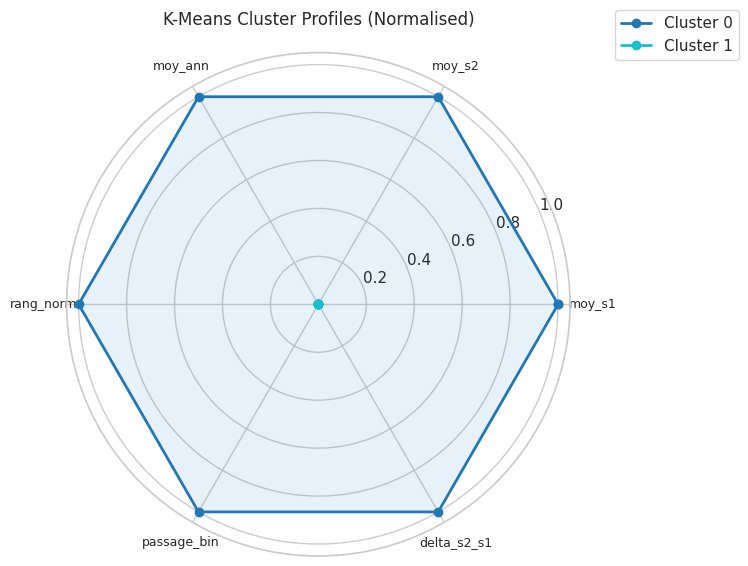

In [10]:
def radar_chart(categories, data_dict, title="Cluster Profiles"):
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(data_dict)))

    for (label, values), color in zip(data_dict.items(), colors):
        vals = list(values) + [values[0]]
        ax.plot(angles, vals, "o-", lw=2, color=color, label=str(label))
        ax.fill(angles, vals, alpha=0.1, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_title(title, size=12, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout()
    return fig

radar_cols = [c for c in ["moy_s1", "moy_s2", "moy_ann", "rang_norm",
                            "passage_bin", "delta_s2_s1"]
              if c in panel_cl.columns]

# Normalise to [0, 1] for radar readability
radar_data = panel_cl.groupby("cluster_km")[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

fig = radar_chart(
    categories=radar_cols,
    data_dict={f"Cluster {cl}": radar_norm.loc[cl].values
               for cl in radar_norm.index},
    title="K-Means Cluster Profiles (Normalised)"
)
plt.savefig(FIG / "cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()


### 7b. Boxplots per Cluster



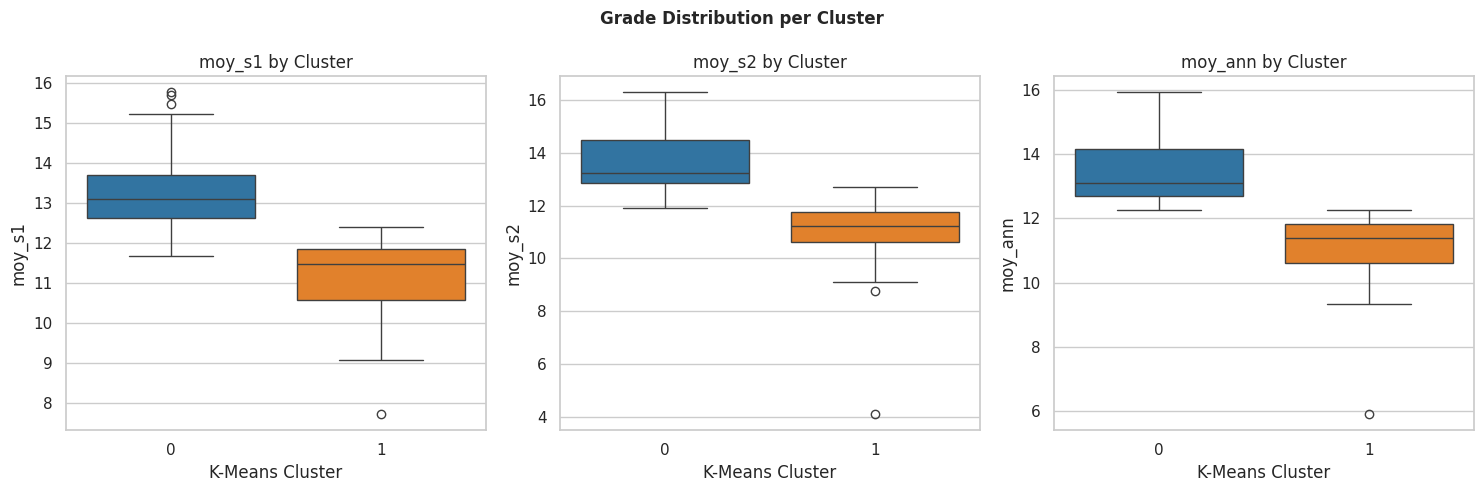

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["moy_s1", "moy_s2", "moy_ann"]):
    sns.boxplot(data=panel_cl, x="cluster_km", y=col, palette="tab10", ax=ax)
    ax.set_title(f"{col} by Cluster")
    ax.set_xlabel("K-Means Cluster")
plt.suptitle("Grade Distribution per Cluster", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG / "cluster_boxplots.png", dpi=150)
plt.show()


## 8. Export Results



In [12]:
panel_cl.to_csv(CLEAN / "panel_clustered.csv", index=False)
print(f"Saved panel_clustered.csv  [{panel_cl.shape}]")
print(f"\nCluster summary (K-Means):")
print(panel_cl.groupby("cluster_km")[["moy_ann", "rang", "passage_bin"]].mean().round(2))


Saved panel_clustered.csv  [(100, 55)]

Cluster summary (K-Means):
            moy_ann  rang  passage_bin
cluster_km                            
0             13.47 10.92         0.97
1             11.06 27.81         0.62
